In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Data Loading**

In [3]:
zip_file_path = '/content/drive/MyDrive/IMDB.zip'

In [4]:
import zipfile
import os
extraction_dir = '/content/drive/MyDrive/IMDB_Extracted_Data'

# Ensure the extraction directory exists
os.makedirs(extraction_dir, exist_ok=True)

# Open the ZIP file and extract its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)
    print(f"Files extracted to {extraction_dir}")

# List the extracted files
extracted_files = os.listdir(extraction_dir)
print("Extracted Files:", extracted_files)

Files extracted to /content/drive/MyDrive/IMDB_Extracted_Data
Extracted Files: ['IMDB Dataset.csv']


In [5]:

import pandas as pd
csv_file_path = '/content/drive/MyDrive/IMDB_Extracted_Data/IMDB Dataset.csv'
df = pd.read_csv(csv_file_path)



In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
#sentiment count
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
# check for duplicates
df.duplicated().sum()

418

**Data Preprocessing**

In [6]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pandas as pd
import nltk
nltk.download('stopwords')
def remove_stopwords(text):
    stop_words = stopwords.words('english')
    words = text.split()
    filtered_sentence = ''
    for word in words:
        if word not in stop_words:
            filtered_sentence = filtered_sentence + word + ' '
    return filtered_sentence.strip()

def normalize_text(text):
    text = text.lower()
    text = re.sub('https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub('\\W', ' ', text)  # Remove non-word characters
    text = re.sub('\n', '', text)  # Remove newlines
    text = re.sub(' +', ' ', text)  # Remove extra spaces
    text = re.sub('^ ', '', text)  # Remove leading space
    text = re.sub(' $', '', text)  # Remove trailing space
    return text

def remove_punctuation(text):
    table = str.maketrans('', '', string.punctuation)
    words = text.split()
    filtered_sentence = ''
    for word in words:
        word = word.translate(table)
        filtered_sentence = filtered_sentence + word + ' '
    return filtered_sentence.strip()

def stemming(text):
    ps = PorterStemmer()
    words = text.split()
    filtered_sentence = ''
    for word in words:
        word = ps.stem(word)
        filtered_sentence = filtered_sentence + word + ' '
    return filtered_sentence.strip()
def preprocess_pipeline(text):
    text = normalize_text(text)
    text = remove_stopwords(text)
    text = remove_punctuation(text)
    text = stemming(text)
    return text



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
df['processed_review'] = df['review'].apply(preprocess_pipeline)
print(df[['review', 'processed_review']].head())


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                    processed_review  
0  one review mention watch 1 oz episod hook righ...  
1  wonder littl product br br film techniqu unass...  
2  thought wonder way spend time hot summer weeke...  
3  basic famili littl boy jake think zombi closet...  
4  petter mattei love time money visual stun film...  


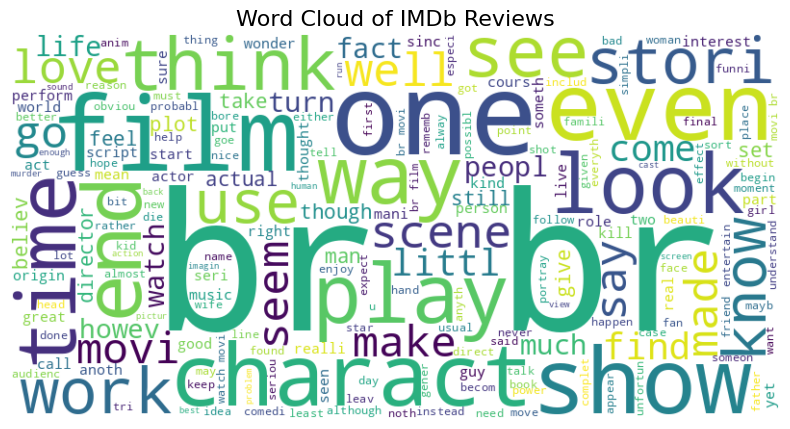

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
all_reviews = " ".join(df['processed_review'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.title('Word Cloud of IMDb Reviews', fontsize=16)
plt.show()


In [8]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['sentiment']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.categories_[0])
df = pd.concat([df, one_hot_df], axis=1)
print(df[['sentiment', 'processed_review'] + list(encoder.categories_[0])].head())

  sentiment                                   processed_review  negative  \
0  positive  one review mention watch 1 oz episod hook righ...       0.0   
1  positive  wonder littl product br br film techniqu unass...       0.0   
2  positive  thought wonder way spend time hot summer weeke...       0.0   
3  negative  basic famili littl boy jake think zombi closet...       1.0   
4  positive  petter mattei love time money visual stun film...       0.0   

   positive  
0       1.0  
1       1.0  
2       1.0  
3       0.0  
4       1.0  


**Feature Engineering:**

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_tfidf = tfidf.fit_transform(df['processed_review'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
feature_names = tfidf.get_feature_names_out()
print(f"Top 10 features: {feature_names[:10]}")


TF-IDF matrix shape: (50000, 5000)
Top 10 features: ['00' '000' '10' '10 10' '10 br' '10 minut' '10 star' '10 year' '100' '11']


In [ ]:

print(df.columns)


Index(['review', 'sentiment', 'processed_review', 'negative', 'positive'], dtype='object')


In [10]:
from sklearn.model_selection import train_test_split
y = df[['negative', 'positive']]
X = X_tfidf
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")


Training set shape: (32000, 5000), Validation set shape: (8000, 5000), Test set shape: (10000, 5000)


**Model building:**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
y_train_labels = y_train.values.argmax(axis=1)
y_val_labels = y_val.values.argmax(axis=1)
logreg_model = LogisticRegression(max_iter=1000)
# Train the model
logreg_model.fit(X_train, y_train_labels)
y_pred = logreg_model.predict(X_val)
print("Classification Report for Validation Set:")
print(classification_report(y_val_labels, y_pred, target_names=['negative', 'positive']))


Classification Report for Validation Set:
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      3959
    positive       0.88      0.89      0.88      4041

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000



In [15]:
import pickle
# Save the TF-IDF Vectorizer
with open('/content/tfidf_vectorizer.pkl', 'wb') as tfidf_file:
    pickle.dump(tfidf, tfidf_file)
# Save the Logistic Regression Model
with open('/content/logistic_model.pkl', 'wb') as model_file:
    pickle.dump(logreg_model, model_file)
print("Models saved successfully")


Models saved successfully


In [16]:
# Load the TF-IDF Vectorizer
with open('/content/tfidf_vectorizer.pkl', 'rb') as tfidf_file:
    loaded_tfidf = pickle.load(tfidf_file)
# Load the Logistic Regression Model
with open('/content/logistic_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

print("Models loaded successfully")


Models loaded successfully


In [14]:
text = "I absolutely loved this movie. It was brilliant!"
# Preprocess the input text
processed_text = preprocess_pipeline(text)
vectorized_text = loaded_tfidf.transform([processed_text])
# Predict sentiment
prediction = loaded_model.predict(vectorized_text)
print(f"Predicted sentiment: {'positive' if prediction[0] == 1 else 'negative'}")


Predicted sentiment: positive
